In [3]:
import json
import os

# ==============================
# 配置部分：请根据你的实际路径修改
# ==============================
input_file_path = "label-gemini-flash-lite-2.5.json"      # 原始数据集路径
output_file_path = "label-gemini-flash-lite-2.5-fixed.json"  # 修复后保存路径

# 检查输入文件是否存在
if not os.path.exists(input_file_path):
    raise FileNotFoundError(f"输入文件不存在: {input_file_path}")

# ==============================
# 加载数据
# ==============================
print("正在加载数据...")
with open(input_file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 确保 data 是一个列表（即包含多个样本）
if not isinstance(data, list):
    raise ValueError("数据应为 JSON 数组（list），每个元素是一条样本。")

print(data[0])  # 打印第一条样本以供检查
print(f"成功加载 {len(data)} 条样本。")

# ==============================
# 修正键名：V4_Symbolic_Visual_Signs → V4_Symbolism
# ==============================
fixed_count = 0
for idx, item in enumerate(data):
    try:
        visual_only = item["cues"]["visual_only"]
        if "V4_Symbolic_Visual_Signs" in visual_only:
            # 将旧键的值移动到新键，并删除旧键
            visual_only["V4_Symbolism"] = visual_only.pop("V4_Symbolic_Visual_Signs")
            fixed_count += 1
    except KeyError as e:
        print(f"警告：第 {idx} 条样本缺少预期字段，跳过。错误: {e}")

print(f"完成修正，共修复 {fixed_count} 条样本中的 'V4_Symbolic_Visual_Signs' 键。")

# ==============================
# 保存修复后的数据
# ==============================
print("正在保存修复后的数据...")
with open(output_file_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print(f"修复完成！已保存至: {output_file_path}")

正在加载数据...
{'analysis_chain': {'visual_observation': "The image shows a close-up of a man, presumably Vladimir Putin, speaking into a microphone. He is wearing a dark jacket with a fur-lined hood. The background is dark with out-of-focus red and blue lights, suggesting a stage or event setting. The man's facial expression is intense, with his mouth open as if speaking emphatically. The lighting is somewhat dramatic, highlighting his features.", 'textual_observation': "The article reports on independent Belarusian filmmakers condemning the Russian invasion of Ukraine. It highlights that many of these filmmakers had fled to Ukraine in 2020 due to their authoritarian homeland. The filmmakers express outrage that Belarusian territory is being used for attacks on Ukraine and demand the withdrawal of Russian troops from both countries. The text uses terms like 'Russian invasion,' 'aggressor,' and 'deadly missiles,' indicating a strong condemnation of Russia's actions. It also mentions the sol

In [ ]:
# 定义需要修正的错误值（可以扩展）
WRONG_VALUES = {
    "Anchoring"   # 如果你也想把含 Mismatch 的都归为 Tension
}

fixed_count = 0

for item in data:
    try:
        cd = item["cues"]["consistency_dimension"]
        current_value = cd.get("D1_Relationship_Type")
        if current_value in WRONG_VALUES:
            cd["D1_Relationship_Type"] = "Semantic Anchoring"  # 修正为合法值
            fixed_count += 1
    except KeyError:
        # 如果路径不存在，跳过（或可根据需要报错）
        continue

print(f"✅ 已修正 {fixed_count} 个样本的 D1_Relationship_Type")

with open(output_file_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

✅ 已将 0 个样本的 D1_Relationship_Type 修正为 'Tension'


In [14]:
import json
import pandas as pd

# ==============================
# 文件路径配置（请根据实际情况修改）
# ==============================
json_file_path = "label-gemini-flash-lite-2.5.json"      # 你的主 JSON 标注文件
csv_file_path = "war_news_data.csv"                      # 包含 image_path / text_path 的 CSV
output_json_path = "label-gemini-flash-lite-2.5_fixed.json"  # 修复后输出文件（可设为原路径以覆盖）

# ==============================
# 1. 加载 JSON 数据
# ==============================
with open(json_file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"✅ 加载 {len(data)} 条 JSON 样本")

# ==============================
# 2. 加载 CSV 并构建 news_id -> (image_path, text_path) 的映射
# ==============================
df = pd.read_csv(csv_file_path, dtype={"news_id": str})  # 强制 news_id 为字符串，避免类型不一致
csv_lookup = {}
for _, row in df.iterrows():
    nid = str(row["news_id"]).strip()
    img_path = row.get("image_path", "")
    txt_path = row.get("text_path", "")
    csv_lookup[nid] = (img_path, txt_path)

print(f"✅ 从 CSV 加载 {len(csv_lookup)} 条 news_id 映射")

# ==============================
# 3. 遍历 JSON 数据，补充缺失字段
# ==============================
filled_count = 0
missing_in_csv = []

for item in data:
    news_id = str(item.get("news_id", "")).strip()
    if not news_id:
        continue  # 跳过没有 news_id 的样本

    has_img = "image_path" in item and item["image_path"]
    has_txt = "text_path" in item and item["text_path"]

    # 如果任一缺失，尝试从 CSV 补充
    if not (has_img and has_txt):
        if news_id in csv_lookup:
            img_p, txt_p = csv_lookup[news_id]
            if not has_img and img_p:
                item["image_path"] = img_p
            if not has_txt and txt_p:
                item["text_path"] = txt_p
            filled_count += 1
        else:
            missing_in_csv.append(news_id)

# ==============================
# 4. 保存修复后的数据
# ==============================
with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

# ==============================
# 5. 输出报告
# ==============================
print(f"\n✅ 修复完成！")
print(f"  - 成功补充 {filled_count} 条样本的 image_path / text_path")
if missing_in_csv:
    print(f"  - ⚠️ 有 {len(missing_in_csv)} 个 news_id 在 CSV 中未找到（例如前5个）:")
    print("    ", missing_in_csv[:5])
else:
    print("  - 所有缺失字段均成功补充！")

print(f"\n💾 已保存至: {output_json_path}")

✅ 加载 22120 条 JSON 样本
✅ 从 CSV 加载 22131 条 news_id 映射

✅ 修复完成！
  - 成功补充 7851 条样本的 image_path / text_path
  - 所有缺失字段均成功补充！

💾 已保存至: label-gemini-flash-lite-2.5_fixed.json


In [13]:
import json

# ==============================
# 配置：替换为你的实际文件路径
# ==============================
input_file_path = "label-gemini-flash-lite-2.5.json"  # ← 请修改为你自己的 JSON 文件路径

# ==============================
# 定义合法取值范围（根据你的要求）
# ==============================
VALID_SUBJECT_TYPES = {
    "Soldier", "Civilian", "Leader", "Mass Crowd", "Other Human", "No Human"
}
VALID_CAMERA_ANGLES = {
    "Low", "High", "Eye-level", "Extreme Close-up", "None"
}
VALID_RELATIONSHIP_TYPES = {
    "Reinforcing", "Tension/Mismatch", "Neutral", "Semantic Anchoring", "Visual Amplification"
}

# ==============================
# 加载数据
# ==============================
with open(input_file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

if not isinstance(data, list):
    raise ValueError("数据应为 JSON 数组（list）")

print(f"✅ 成功加载 {len(data)} 条样本。开始校验...")

# ==============================
# 校验函数
# ==============================
def validate_sample(item):
    errors = []
    news_id = item.get("news_id", "<unknown>")

    # --- 1. analysis_chain ---
    ac = item.get("analysis_chain", {})
    for key in ["visual_observation", "textual_observation", "joint_mechanism"]:
        if key not in ac or not isinstance(ac[key], str):
            errors.append(f"analysis_chain.{key} 缺失或非字符串")

    # --- 2. cues ---
    cues = item.get("cues", {})

    # visual_only
    vo = cues.get("visual_only", {})
    for v_key in ["V1_Salience", "V2_Perspective", "V3_Color_Lighting", "V4_Symbolism"]:
        cue = vo.get(v_key, {})
        if not cue:
            errors.append(f"cues.visual_only.{v_key} 缺失")
            continue
        # present 必须是 bool
        if "present" not in cue or not isinstance(cue["present"], bool):
            errors.append(f"{v_key}.present 缺失或非布尔值")
        # score 必须是 0-3 整数
        if "score" not in cue or not isinstance(cue["score"], int) or not (0 <= cue["score"] <= 3):
            errors.append(f"{v_key}.score 不在 0-3 范围内或非整数")
        # reason 必须是字符串
        if "reason" not in cue or not isinstance(cue["reason"], str):
            errors.append(f"{v_key}.reason 缺失或非字符串")

        # V2_Perspective 特有 analysis 字段
        if v_key == "V2_Perspective":
            analysis = cue.get("analysis", {})
            if not analysis:
                errors.append("V2_Perspective.analysis 缺失")
            else:
                st = analysis.get("subject_type")
                if st not in VALID_SUBJECT_TYPES:
                    errors.append(f"V2_Perspective.analysis.subject_type 非法值: {st}")
                ca = analysis.get("camera_angle")
                if ca not in VALID_CAMERA_ANGLES:
                    errors.append(f"V2_Perspective.analysis.camera_angle 非法值: {ca}")

    # text_only
    to = cues.get("text_only", {})
    for t_key in ["T1_Loaded_Language", "T2_Moral_Judgment"]:
        cue = to.get(t_key, {})
        if not cue:
            errors.append(f"cues.text_only.{t_key} 缺失")
            continue
        if "present" not in cue or not isinstance(cue["present"], bool):
            errors.append(f"{t_key}.present 缺失或非布尔值")
        if "score" not in cue or not isinstance(cue["score"], int) or not (0 <= cue["score"] <= 3):
            errors.append(f"{t_key}.score 不在 0-3 范围内或非整数")
        if "reason" not in cue or not isinstance(cue["reason"], str):
            errors.append(f"{t_key}.reason 缺失或非字符串")

    # joint_multimodal
    jm = cues.get("joint_multimodal", {})
    for j_key in ["J1_Role_Framing", "J2_Selective_Imbalance", "J3_Stereotyping"]:
        cue = jm.get(j_key, {})
        if not cue:
            errors.append(f"cues.joint_multimodal.{j_key} 缺失")
            continue
        if "present" not in cue or not isinstance(cue["present"], bool):
            errors.append(f"{j_key}.present 缺失或非布尔值")
        if "reason" not in cue or not isinstance(cue["reason"], str):
            errors.append(f"{j_key}.reason 缺失或非字符串")

    # consistency_dimension
    cd = cues.get("consistency_dimension", {})
    if not cd:
        errors.append("cues.consistency_dimension 缺失")
    else:
        rel_type = cd.get("D1_Relationship_Type")
        if rel_type not in VALID_RELATIONSHIP_TYPES:
            errors.append(f"D1_Relationship_Type 非法值: {rel_type}")
        coherence = cd.get("Coherence_Score")
        if not isinstance(coherence, int) or not (0 <= coherence <= 5):
            errors.append(f"Coherence_Score 不在 0-5 范围内或非整数")
        if "reason" not in cd or not isinstance(cd["reason"], str):
            errors.append("consistency_dimension.reason 缺失或非字符串")

    # overall_bias_intensity
    bias = item.get("overall_bias_intensity")
    if not isinstance(bias, int) or not (0 <= bias <= 5):
        errors.append("overall_bias_intensity 不在 0-5 范围内或非整数")

    return news_id, errors

# ==============================
# 执行校验
# ==============================
all_errors = []
valid_count = 0

for item in data:
    news_id, errors = validate_sample(item)
    if errors:
        all_errors.append((news_id, errors))
    else:
        valid_count += 1

# ==============================
# 输出结果
# ==============================
print(f"\n📊 校验完成！")
print(f"✅ 符合规范的样本数: {valid_count}")
print(f"❌ 存在问题的样本数: {len(all_errors)}\n")

if all_errors:
    print("🔍 详细错误列表：")
    for news_id, errors in all_errors:
        print(f"\n📰 news_id: {news_id}")
        for err in errors:
            print(f"   - {err}")
else:
    print("🎉 所有样本均符合格式规范！")

✅ 成功加载 22120 条样本。开始校验...

📊 校验完成！
✅ 符合规范的样本数: 19788
❌ 存在问题的样本数: 2332

🔍 详细错误列表：

📰 news_id: 2
   - V2_Perspective.analysis.subject_type 非法值: Eye-level
   - V2_Perspective.analysis.camera_angle 非法值: None

📰 news_id: 15
   - V2_Perspective.analysis.camera_angle 非法值: High Angle

📰 news_id: 16
   - V2_Perspective.analysis 缺失

📰 news_id: 36
   - V2_Perspective.analysis.subject_type 非法值: Soldier / Civilian / Leader / Mass Crowd / Other Human / No Human

📰 news_id: 38
   - V2_Perspective.analysis.camera_angle 非法值: Low / Eye-level

📰 news_id: 40
   - V2_Perspective.analysis.subject_type 非法值: Soldier / Civilian / Leader / Mass Crowd / Other Human / No Human
   - V2_Perspective.analysis.camera_angle 非法值: Eye-level / None

📰 news_id: 71
   - V2_Perspective.analysis 缺失

📰 news_id: 72
   - V2_Perspective.analysis.subject_type 非法值: Mass Crowd / Civilian

📰 news_id: 73
   - V2_Perspective.analysis.subject_type 非法值: Individual

📰 news_id: 75
   - V2_Perspective.analysis.subject_type 非法值: Player / Refe

In [1]:
#先导入目标csv：
import pandas as pd
from sklearn.model_selection import train_test_split 
df = pd.read_csv("label-gemini-flash-lite-2.5.csv")
df = df.dropna(subset=["D1_Relationship_Type"]).reset_index(drop=True)


# Split — we use val as test per your choice
_, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["D1_Relationship_Type"])


# 1) 检查每个 indicator 在 val 集的正例数量（support）
presence_cols = [
 "V1_Salience.present","V2_Perspective.present","V3_Color_Lighting.present",
 "V4_Symbolism.present","T1_Loaded_Language.present","T2_Moral_Judgment.present",
 "J1_Role_Framing.present","J2_Selective_Imbalance.present","J3_Stereotyping.present"
]
print("Presence positive counts (val):")
print(val_df[presence_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum())

# # 2) 检查 J3 的 confusion（预测 vs 真实）
# # 假设 presence_preds 与 presence_labels 是 numpy arrays (N,9) 得自 evaluate 脚本
# i = presence_cols.index("J3_Stereotyping.present")
# from sklearn.metrics import confusion_matrix
# print("J3 CM:\n", confusion_matrix(presence_labels[:,i], presence_preds[:,i]))

# 3) 检查 D1 类别分布（val）
print("D1 distribution (val):")
print(val_df["D1_Relationship_Type"].value_counts())


Presence positive counts (val):
V1_Salience.present               1091
V2_Perspective.present            3789
V3_Color_Lighting.present          977
V4_Symbolism.present              2390
T1_Loaded_Language.present        2800
T2_Moral_Judgment.present         1898
J1_Role_Framing.present           2283
J2_Selective_Imbalance.present    2012
J3_Stereotyping.present             97
dtype: int64
D1 distribution (val):
D1_Relationship_Type
Visual Amplification    1706
Semantic Anchoring      1340
Reinforcing              965
Neutral                  215
Tension/Mismatch         191
Name: count, dtype: int64


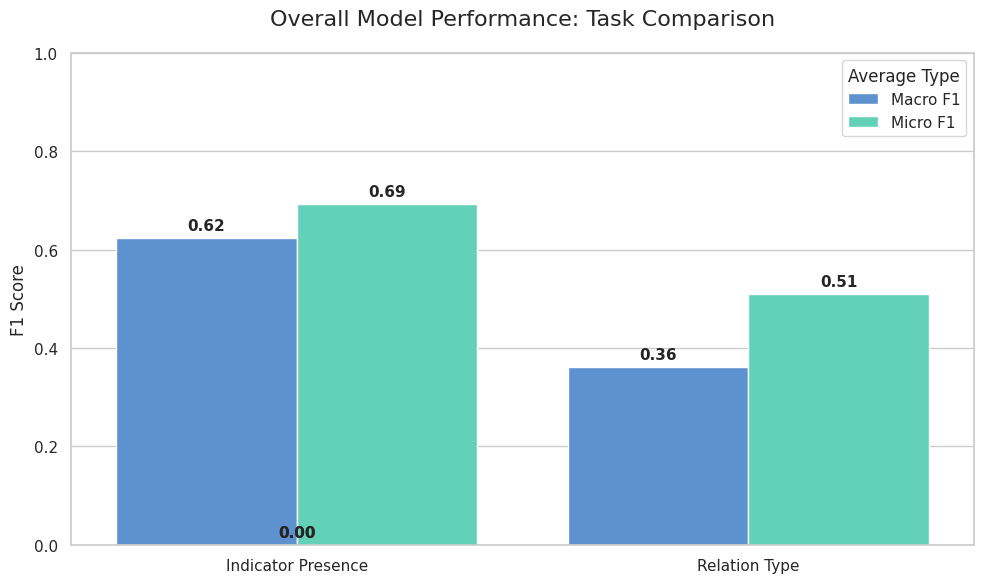

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 准备数据
data = {
    'Task': ['Indicator Presence', 'Indicator Presence', 'Relation Type', 'Relation Type'],
    'Average Type': ['Macro F1', 'Micro F1', 'Macro F1', 'Micro F1'],
    'Score': [0.6234, 0.6924, 0.3612, 0.5105]
}
df_overall = pd.DataFrame(data)

# 2. 绘图
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 使用特定的颜色区分指标类型
palette = {"Macro F1": "#4A90E2", "Micro F1": "#50E3C2"}
ax = sns.barplot(data=df_overall, x='Task', y='Score', hue='Average Type', palette=palette)

# 3. 装饰
plt.title('Overall Model Performance: Task Comparison', fontsize=16, pad=20)
plt.ylim(0, 1.0)
plt.ylabel('F1 Score')
plt.xlabel('')

# 添加数值标注
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()